## Diffusion Equation
### 1. Analytical Approach
$$
    \frac{\partial T}{\partial t} = D \frac{\partial^2 T}{\partial x^2}
$$
* $T$: distribution (often temperature)
* $D$: constant diffusion coefficient

Plugging $T(x,t) = g(x)f(t)$ into diffusion equation gives:
$$
    \frac{1}{D} \frac{\dot{f}(t)}{f(t)} = \frac{g''(x)}{g(x)}
$$
Left hand side is only time dependent, while right hand side is only position (space) dependent. Say, both sides are equal to a constant: $a^2$, accordingly;
$$
    \dot{f}(t) = -\gamma f(t) \quad \text{where,} \, \gamma = a^2 D \quad \text{so that, } \, f(t) = e^{-\gamma t}
$$
On the other hand $g(x)$:
$$
    g''(x) + a^2 g(x) = 0
$$
What we have here is one first order and one second ordinary differential equation. We need to solve both. Let's start with left hand side:

In [28]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp

### 2. Symbolic solution (sympy)

In [30]:
x = sp.symbols('x')
a = sp.symbols('a', real=True)
g = sp.Function('g')

ode = sp.Eq(g(x).diff(x, 2) + a**2 * g(x), 0)

sol = sp.dsolve(ode)
print(sol)

Eq(g(x), C1*sin(x*Abs(a)) + C2*cos(a*x))


### 2. Numerical solution (with scipy)
For numerical approach we need to transform it into sum of first order differential equations (because it is second order this results with two of them):

Let:
* $y_0 = g$
* $y_1 = g'$

Then:
* $y_0' = y_1$
* $y_1' = -a^2 y_0$

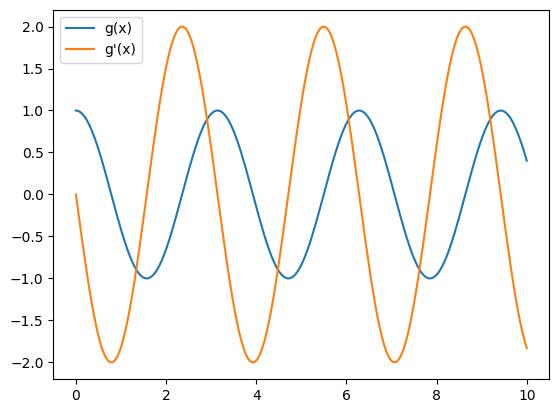

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# a is a constant
a = 2.0

def system(x, y):
    return [y[1], -a**2 * y[0]]

# initial conditions: g(0)=1, g'(0)=0
y0 = [1, 0]

# interval for x
x_span = (0, 10)
x_eval = np.linspace(0, 10, 200)

sol = solve_ivp(system, x_span, y0, t_eval=x_eval)

plt.plot(sol.t, sol.y[0], label="g(x)")
plt.plot(sol.t, sol.y[1], label="g'(x)")
plt.legend()
plt.show()